# MassMIND Data Pipeline — Exploration & Sanity Checks

Visual sanity checks for the data pipeline before training any model. Run from the project root:

```bash
cd massmind_segmentation
python scripts/download.py    # one-time, ~few hundred MB from Google Drive
python -m src.splits          # writes data/splits/split.json
python -m src.stats           # writes data/splits/stats.json
jupyter lab notebooks/01_data_exploration.ipynb
```

What this notebook checks:

1. **Random sample inspection** — 6 training images with mask overlays.
2. **Per-pipeline augmentation comparison** — same image under A/B/C.
3. **Per-class pixel distribution** vs. MassMIND paper Table 5.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

# Make project root importable when running the notebook from notebooks/.
_PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from tqdm.auto import tqdm

from src.augmentations import build_pipeline
from src.dataset import NUM_CLASSES, MassMINDDataset
from src.splits import generate_splits, load_splits
from src.stats import compute_stats, load_stats

DATA_ROOT = _PROJECT_ROOT / 'data' / 'massmind'
SPLIT_PATH = _PROJECT_ROOT / 'data' / 'splits' / 'split.json'
STATS_PATH = _PROJECT_ROOT / 'data' / 'splits' / 'stats.json'

print('project root :', _PROJECT_ROOT)
print('data root    :', DATA_ROOT, '(exists)' if DATA_ROOT.exists() else '(missing — run scripts/download.py)')
print('split file   :', SPLIT_PATH, '(exists)' if SPLIT_PATH.exists() else '(missing — run python -m src.splits)')
print('stats file   :', STATS_PATH, '(exists)' if STATS_PATH.exists() else '(missing — run python -m src.stats)')

/Users/lh/projects/foundation_models/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


project root : /Users/lh/projects/computervision/Assignment 2/code/massmind_segmentation
data root    : /Users/lh/projects/computervision/Assignment 2/code/massmind_segmentation/data/massmind (exists)
split file   : /Users/lh/projects/computervision/Assignment 2/code/massmind_segmentation/data/splits/split.json (exists)
stats file   : /Users/lh/projects/computervision/Assignment 2/code/massmind_segmentation/data/splits/stats.json (exists)


## 0. Lazy-init: generate splits and stats if missing

Idempotent — does nothing if both already exist.

In [2]:
if not SPLIT_PATH.exists():
    generate_splits(DATA_ROOT, SPLIT_PATH)
if not STATS_PATH.exists():
    compute_stats(DATA_ROOT, SPLIT_PATH, STATS_PATH)

splits = load_splits(SPLIT_PATH)
mean, std = load_stats(STATS_PATH)
print(f'splits: train={len(splits["train"])}, val={len(splits["val"])}, test={len(splits["test"])}')
print(f'stats : mean={mean:.4f}, std={std:.4f}')

splits: train=2042, val=583, test=291
stats : mean=0.5067, std=0.1960


## 1. Random training samples with mask overlay

Six random training samples shown as image, mask, and overlay.

In [3]:
# Distinct, semantically-suggestive colours per class. Order: Sky, Water, Bridge,
# Obstacle, Living obstacle, Background, Self.
CLASS_NAMES = ['Sky', 'Water', 'Bridge', 'Obstacle', 'Living obs', 'Background', 'Self']
CLASS_COLORS = np.array([
    [0.55, 0.78, 0.92],  # sky blue
    [0.13, 0.32, 0.58],  # water (deep blue)
    [0.55, 0.27, 0.07],  # bridge (brown)
    [0.95, 0.30, 0.20],  # obstacle (red)
    [1.00, 1.00, 0.10],  # living obstacle (yellow)
    [0.40, 0.40, 0.40],  # background (grey)
    [0.20, 0.85, 0.30],  # self (green)
], dtype=np.float32)
MASK_CMAP = ListedColormap(CLASS_COLORS)


def colorize_mask(mask: np.ndarray) -> np.ndarray:
    """Map a [H, W] uint8 mask to an RGB float32 image in [0, 1]."""
    rgb = np.zeros((*mask.shape, 3), dtype=np.float32)
    for cls in range(NUM_CLASSES):
        rgb[mask == cls] = CLASS_COLORS[cls]
    return rgb


def overlay(image_gray: np.ndarray, mask: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    rgb_image = np.repeat(image_gray[..., None], 3, axis=-1)
    rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min() + 1e-8)
    rgb_mask = colorize_mask(mask)
    return (1 - alpha) * rgb_image + alpha * rgb_mask

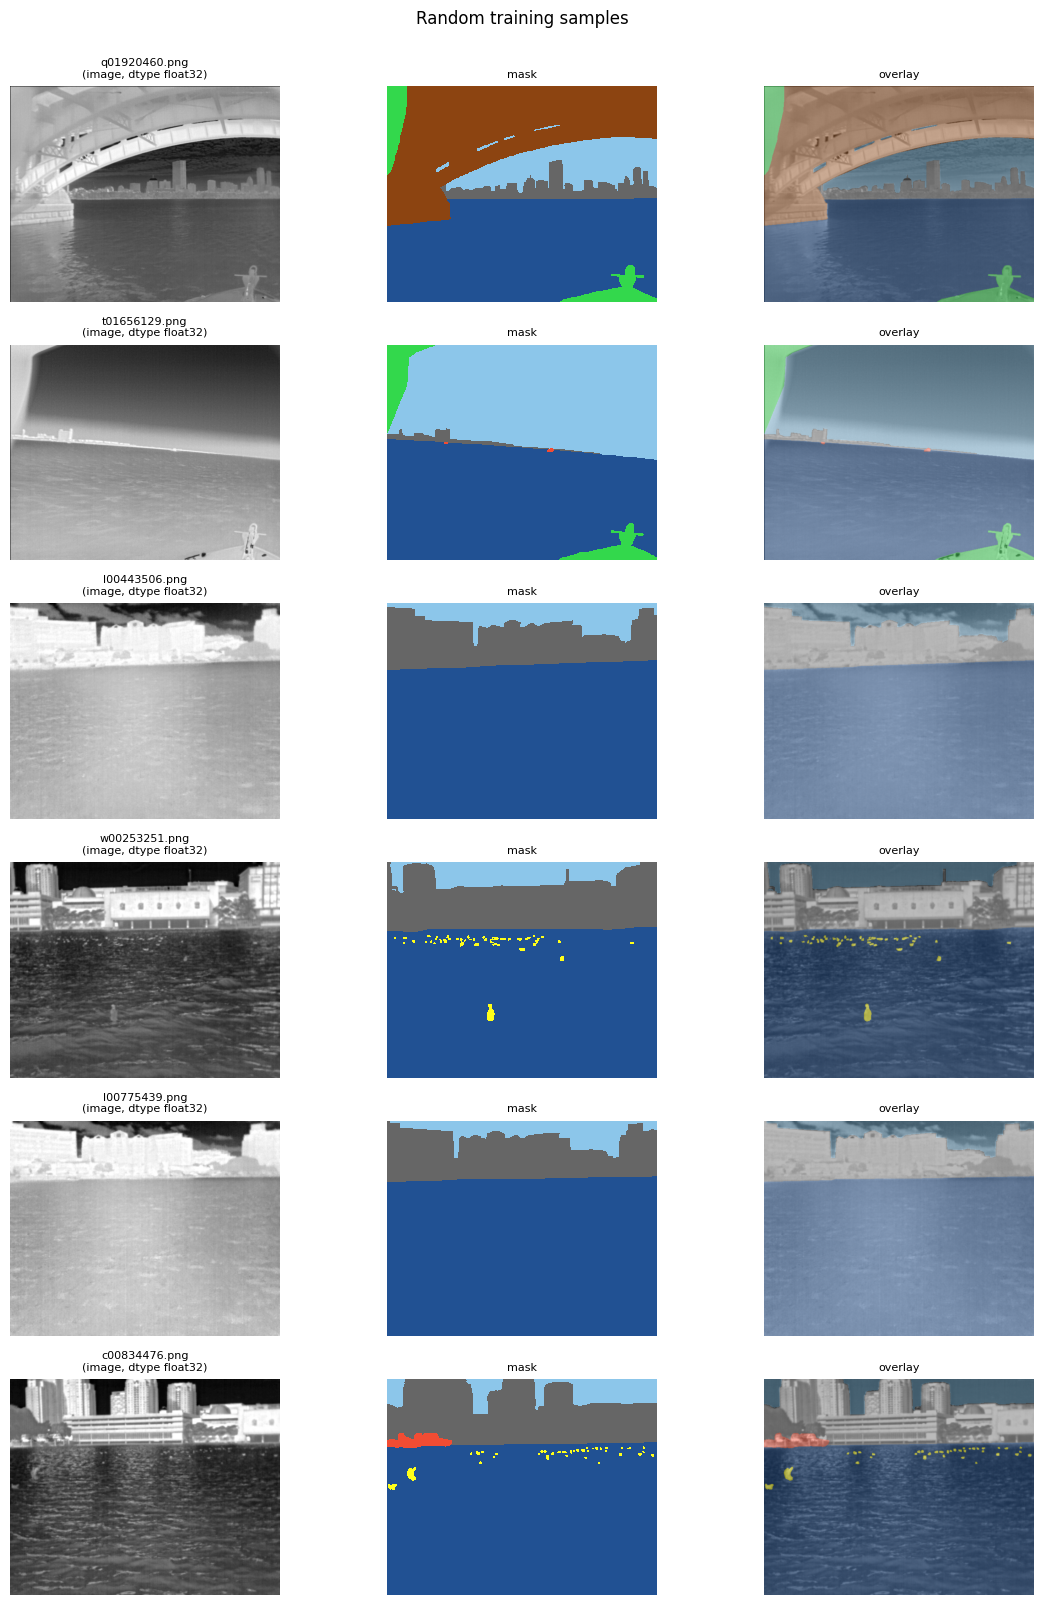

In [4]:
rng = np.random.default_rng(42)
sample_names = rng.choice(splits['train'], size=6, replace=False).tolist()

fig, axes = plt.subplots(6, 3, figsize=(12, 16))
for row, name in enumerate(sample_names):
    img = cv2.imread(str(DATA_ROOT / 'data' / name), cv2.IMREAD_UNCHANGED)
    msk = cv2.imread(str(DATA_ROOT / 'mask' / name), cv2.IMREAD_UNCHANGED)
    if img.dtype == np.uint16:
        img = img.astype(np.float32) / 65535.0
    else:
        img = img.astype(np.float32) / 255.0
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'{name}\n(image, dtype {img.dtype})', fontsize=8)
    axes[row, 1].imshow(msk, cmap=MASK_CMAP, vmin=0, vmax=NUM_CLASSES - 1, interpolation='nearest')
    axes[row, 1].set_title('mask', fontsize=8)
    axes[row, 2].imshow(overlay(img, msk))
    axes[row, 2].set_title('overlay', fontsize=8)
    for ax in axes[row]:
        ax.axis('off')
fig.suptitle('Random training samples', fontsize=12, y=1.0)
fig.tight_layout()

## 2. Augmentation pipeline comparison

Same training image under Pipeline A (paper-replicated), Pipeline B (extended), and Pipeline C (none).

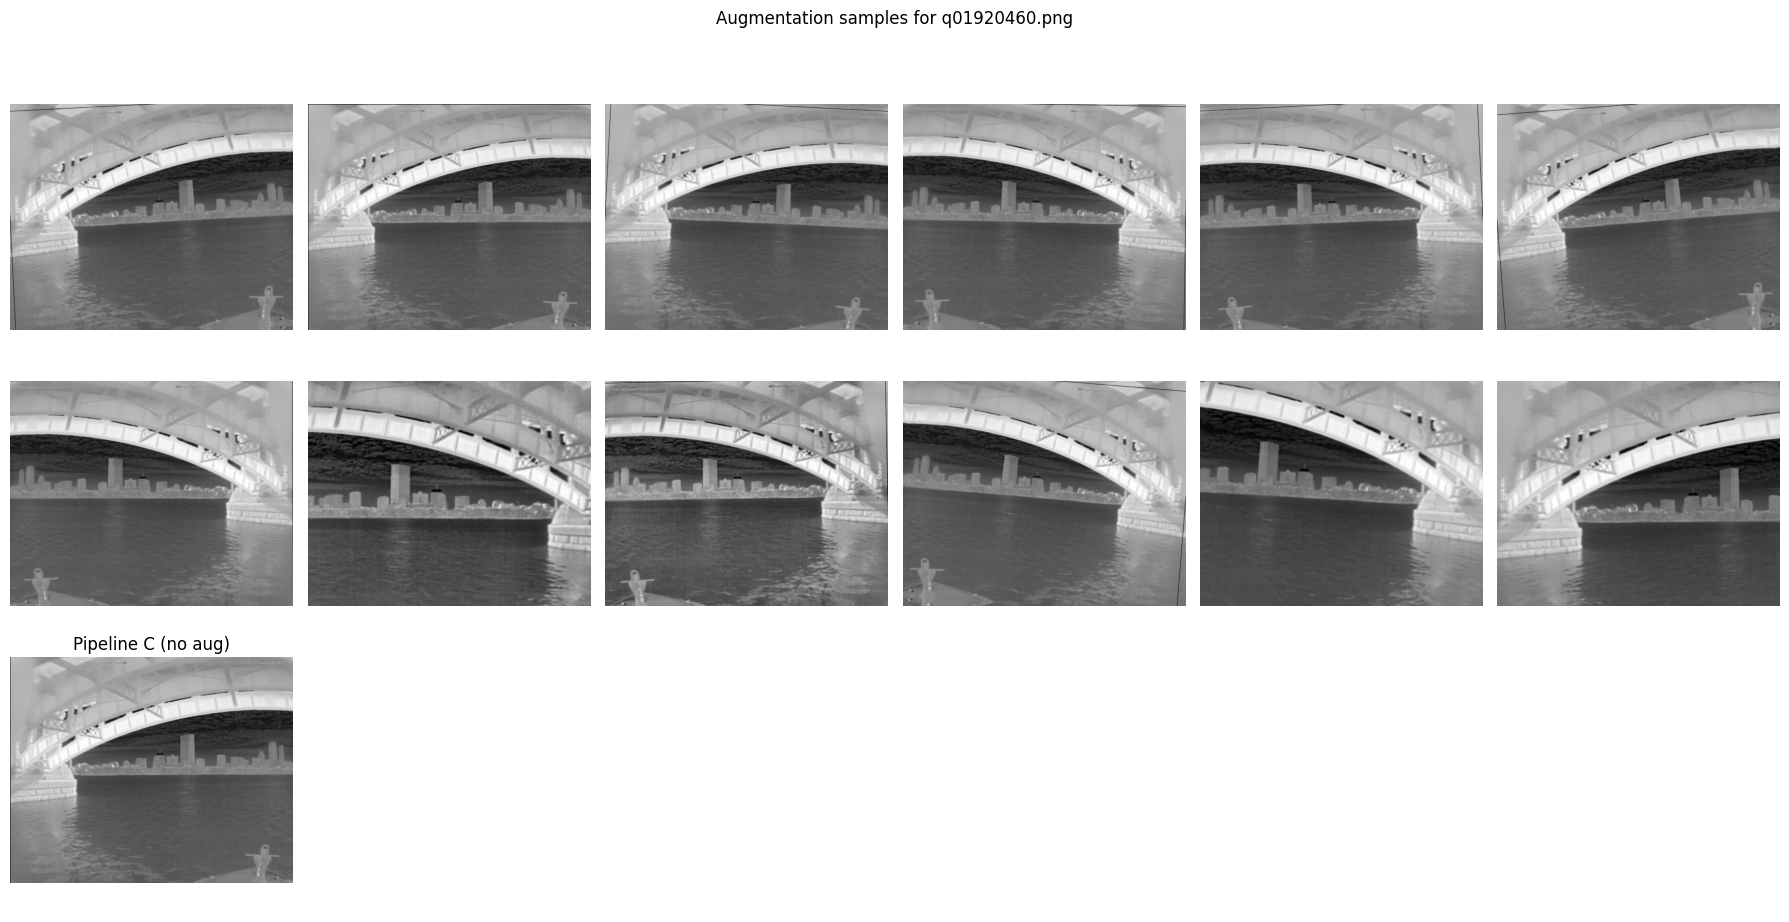

In [5]:
anchor_name = sample_names[0]

ds_A = MassMINDDataset(DATA_ROOT, [anchor_name] * 6, build_pipeline('A', mean, std, train=True))
ds_B = MassMINDDataset(DATA_ROOT, [anchor_name] * 6, build_pipeline('B', mean, std, train=True))
ds_C = MassMINDDataset(DATA_ROOT, [anchor_name] * 1, build_pipeline('C', mean, std, train=False))

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for col in range(6):
    s = ds_A[col]
    axes[0, col].imshow(s['image'].squeeze(0).numpy(), cmap='gray')
    axes[0, col].axis('off')
    s = ds_B[col]
    axes[1, col].imshow(s['image'].squeeze(0).numpy(), cmap='gray')
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('Pipeline A', rotation=90, size='large')
axes[1, 0].set_ylabel('Pipeline B', rotation=90, size='large')

s = ds_C[0]
axes[2, 0].imshow(s['image'].squeeze(0).numpy(), cmap='gray')
axes[2, 0].axis('off')
axes[2, 0].set_title('Pipeline C (no aug)')
for col in range(1, 6):
    axes[2, col].axis('off')

fig.suptitle(f'Augmentation samples for {anchor_name}', y=1.02)
fig.tight_layout()

## 3. Per-class pixel distribution vs. paper Table 5

Counts pixels across the full training split. For 2,000+ images this can take 1–2 minutes — caches the result so subsequent runs are instant.

In [6]:
PAPER_FRACTIONS = {
    'Sky': 0.3058, 'Water': 0.5221, 'Bridge': 0.0167, 'Obstacle': 0.0094,
    'Living obs': 0.0005, 'Background': 0.1128, 'Self': 0.0325,
}

CACHE = _PROJECT_ROOT / 'data' / 'splits' / 'class_pixel_counts.json'

if CACHE.exists():
    counts = np.array(json.loads(CACHE.read_text()))
    print(f'Loaded cached counts from {CACHE}')
else:
    counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    for name in tqdm(splits['train'], desc='counting pixels'):
        msk = cv2.imread(str(DATA_ROOT / 'mask' / name), cv2.IMREAD_UNCHANGED)
        if msk is None:
            continue
        for cls in range(NUM_CLASSES):
            counts[cls] += int((msk == cls).sum())
    CACHE.write_text(json.dumps(counts.tolist()))
    print(f'Wrote cache to {CACHE}')

total = counts.sum()
fractions = counts / total
print(f'Total pixels analysed: {total:,}')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i} {name:<12}  observed={fractions[i]:.4f}   paper={PAPER_FRACTIONS[name]:.4f}')

counting pixels:   0%|          | 0/2042 [00:00<?, ?it/s]

counting pixels:   3%|▎         | 61/2042 [00:00<00:03, 603.63it/s]

counting pixels:   6%|▌         | 124/2042 [00:00<00:03, 614.08it/s]

counting pixels:   9%|▉         | 187/2042 [00:00<00:02, 619.32it/s]

counting pixels:  12%|█▏        | 251/2042 [00:00<00:02, 625.17it/s]

...

counting pixels:  93%|█████████▎| 1898/2042 [00:02<00:00, 661.04it/s]

counting pixels:  96%|█████████▌| 1965/2042 [00:03<00:00, 660.94it/s]

counting pixels: 100%|█████████▉| 2032/2042 [00:03<00:00, 659.71it/s]

counting pixels: 100%|██████████| 2042/2042 [00:03<00:00, 646.26it/s]

Wrote cache to /Users/lh/projects/computervision/Assignment 2/code/massmind_segmentation/data/splits/class_pixel_counts.json
Total pixels analysed: 669,122,560
  0 Sky           observed=0.3089   paper=0.3058
  1 Water         observed=0.5215   paper=0.5221
  2 Bridge        observed=0.0166   paper=0.0167
  3 Obstacle      observed=0.0095   paper=0.0094
  4 Living obs    observed=0.0005   paper=0.0005
  5 Background    observed=0.1115   paper=0.1128
  6 Self          observed=0.0315   paper=0.0325


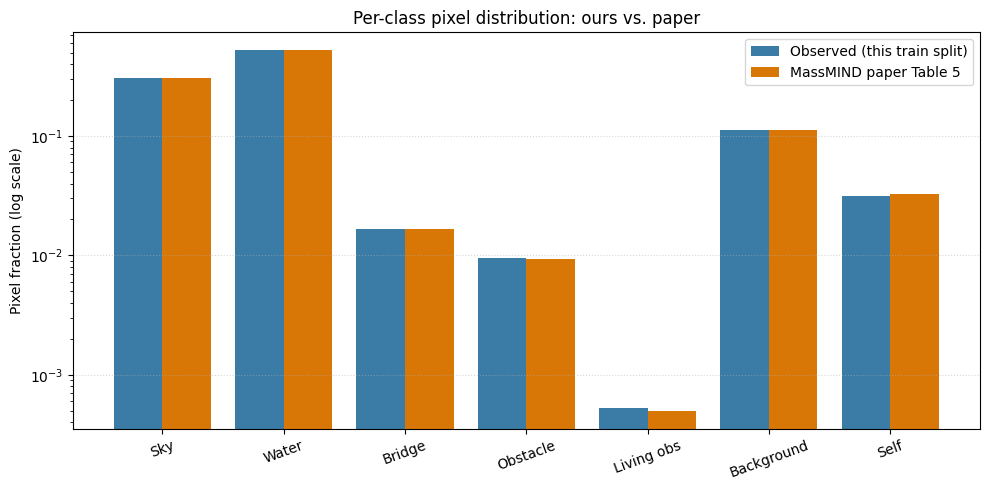

In [7]:
x = np.arange(NUM_CLASSES)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, fractions, width=0.4, label='Observed (this train split)', color='#3a7ca5')
ax.bar(x + 0.2, [PAPER_FRACTIONS[n] for n in CLASS_NAMES], width=0.4, label='MassMIND paper Table 5', color='#d97706')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20)
ax.set_ylabel('Pixel fraction (log scale)')
ax.set_title('Per-class pixel distribution: ours vs. paper')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)
fig.tight_layout()

## Summary

If the bar chart roughly matches paper Table 5 (especially that water dominates and living obstacles are at ~0.05%), the pipeline is loading masks correctly. Significant divergence — especially Sky and Water swapped — would suggest a class-ID remapping bug somewhere in the chain.

**Next phase**: model architectures (SegFormer MiT-B2, U-Net + VGG-16), single-channel first-layer adaptation, and the training loop.